In [87]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [88]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [89]:
matplotlib.rcParams['figure.figsize'] = (20.0, 20.0)

# Leitura e conversão da imagem para grayscale

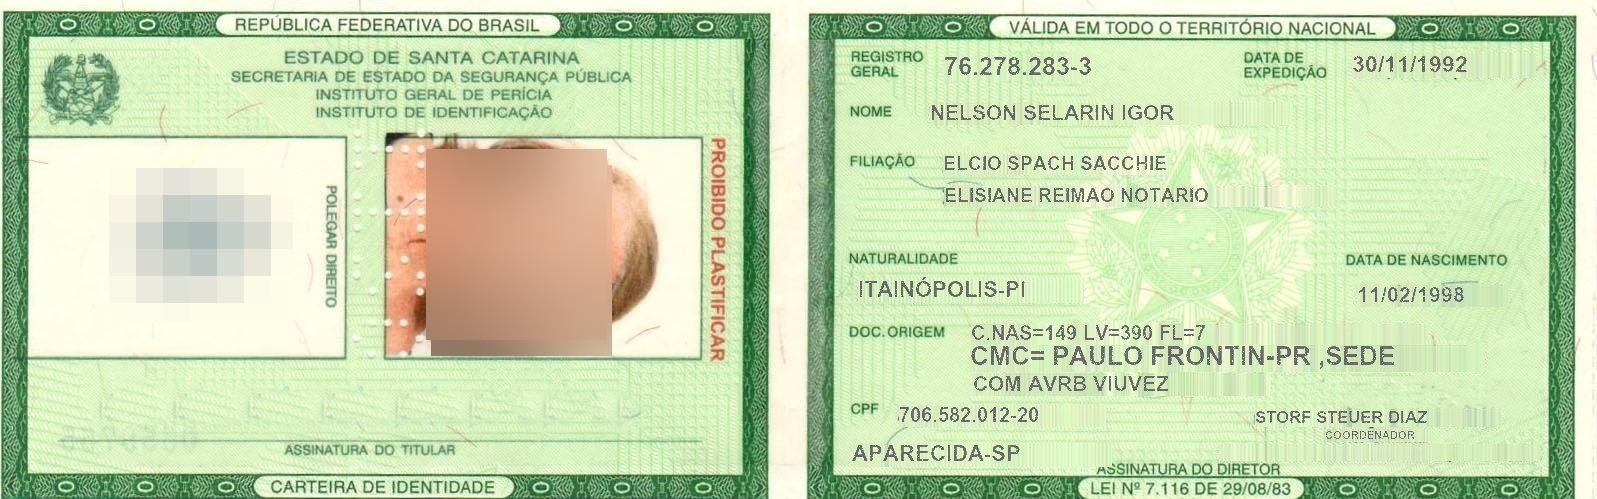

In [90]:
image = cv2.imread('/content/drive/MyDrive/ComputerVision/IdsDataset/00018418_in.jpg')
cv2_imshow(image)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Filtros de suavização


1.   Suavização da imagem em grayscale usando filtro de média.
2.   Aplicação do filtro de mediana para eliminação de ruído.



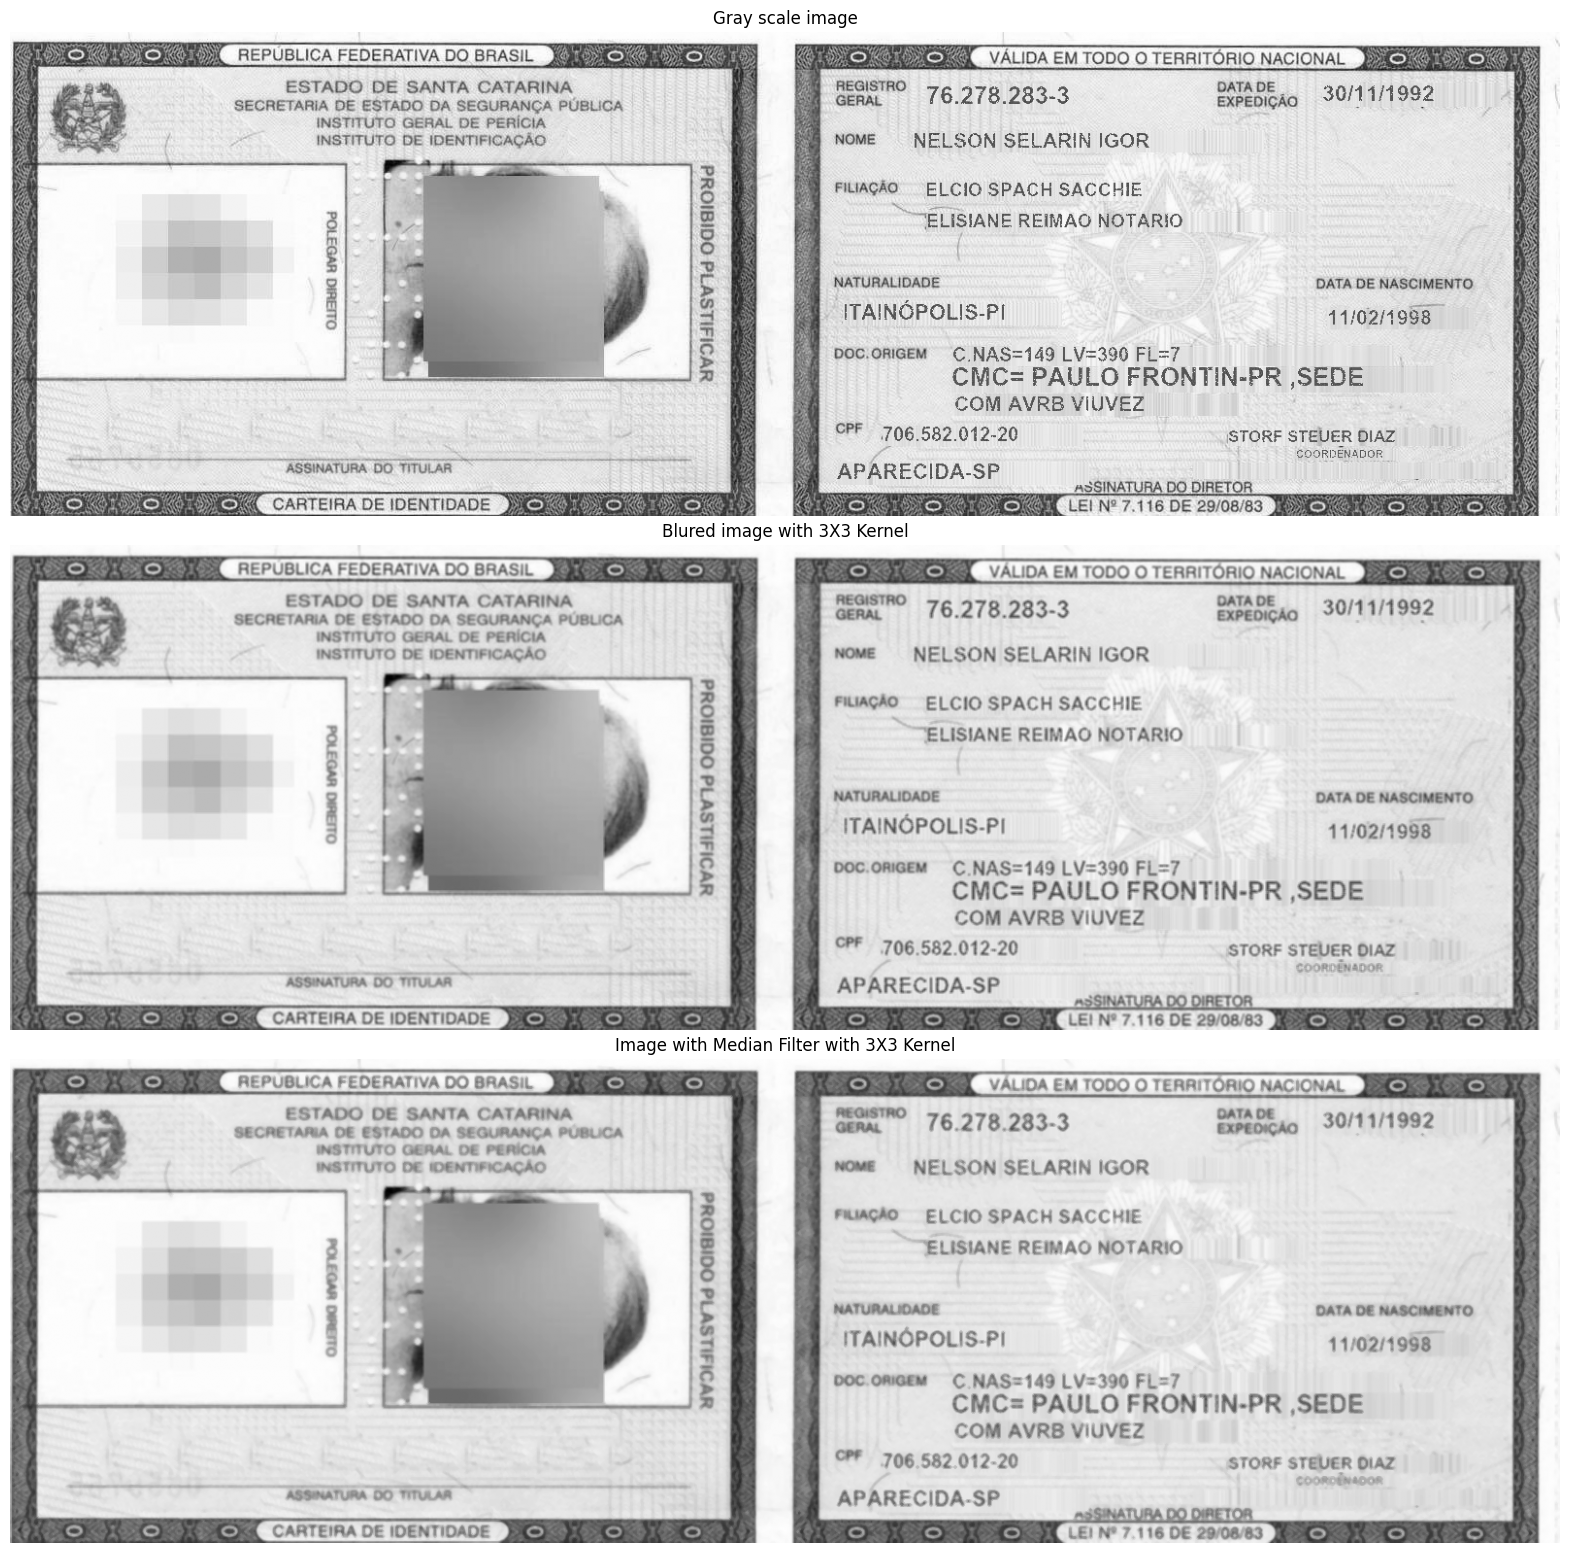

In [91]:
plt.subplot(3, 1, 1)
plt.imshow(gray, cmap='gray')
plt.title('Gray scale image')
plt.axis('off')

blur = cv2.blur(gray, (3,3))
plt.subplot(3, 1, 2)
plt.imshow(blur, cmap='gray')
plt.title('Blured image with 3X3 Kernel')
plt.axis('off')

blur = cv2.medianBlur(blur, 3)
plt.subplot(3, 1, 3)
plt.imshow(blur, cmap='gray')
plt.title('Image with Median Filter with 3X3 Kernel')
plt.axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

In [92]:
matplotlib.rcParams['figure.figsize'] = (20.0, 20.0)

# Aplicação de filtro de threshold

O filtro foi aplicado a 3 imagens para comparação nos valores de threshold onde o valor dos pixels abaixo do valor de threshold o pixel terá valor 0 e caso estaja acima do valor de threshold o valor do pixel irá para 255

1.   Primeira imagem com valor de 120 onde algumas letras não ficam com uma boa nitidez.
2.   Segunda imagem onde o valor é de 155 e apresenta um bom balanço entre nitidez e ruído.
3.   Terceira imagem onde o valor é de 200 e apresenta uma quantidade alta de ruído.



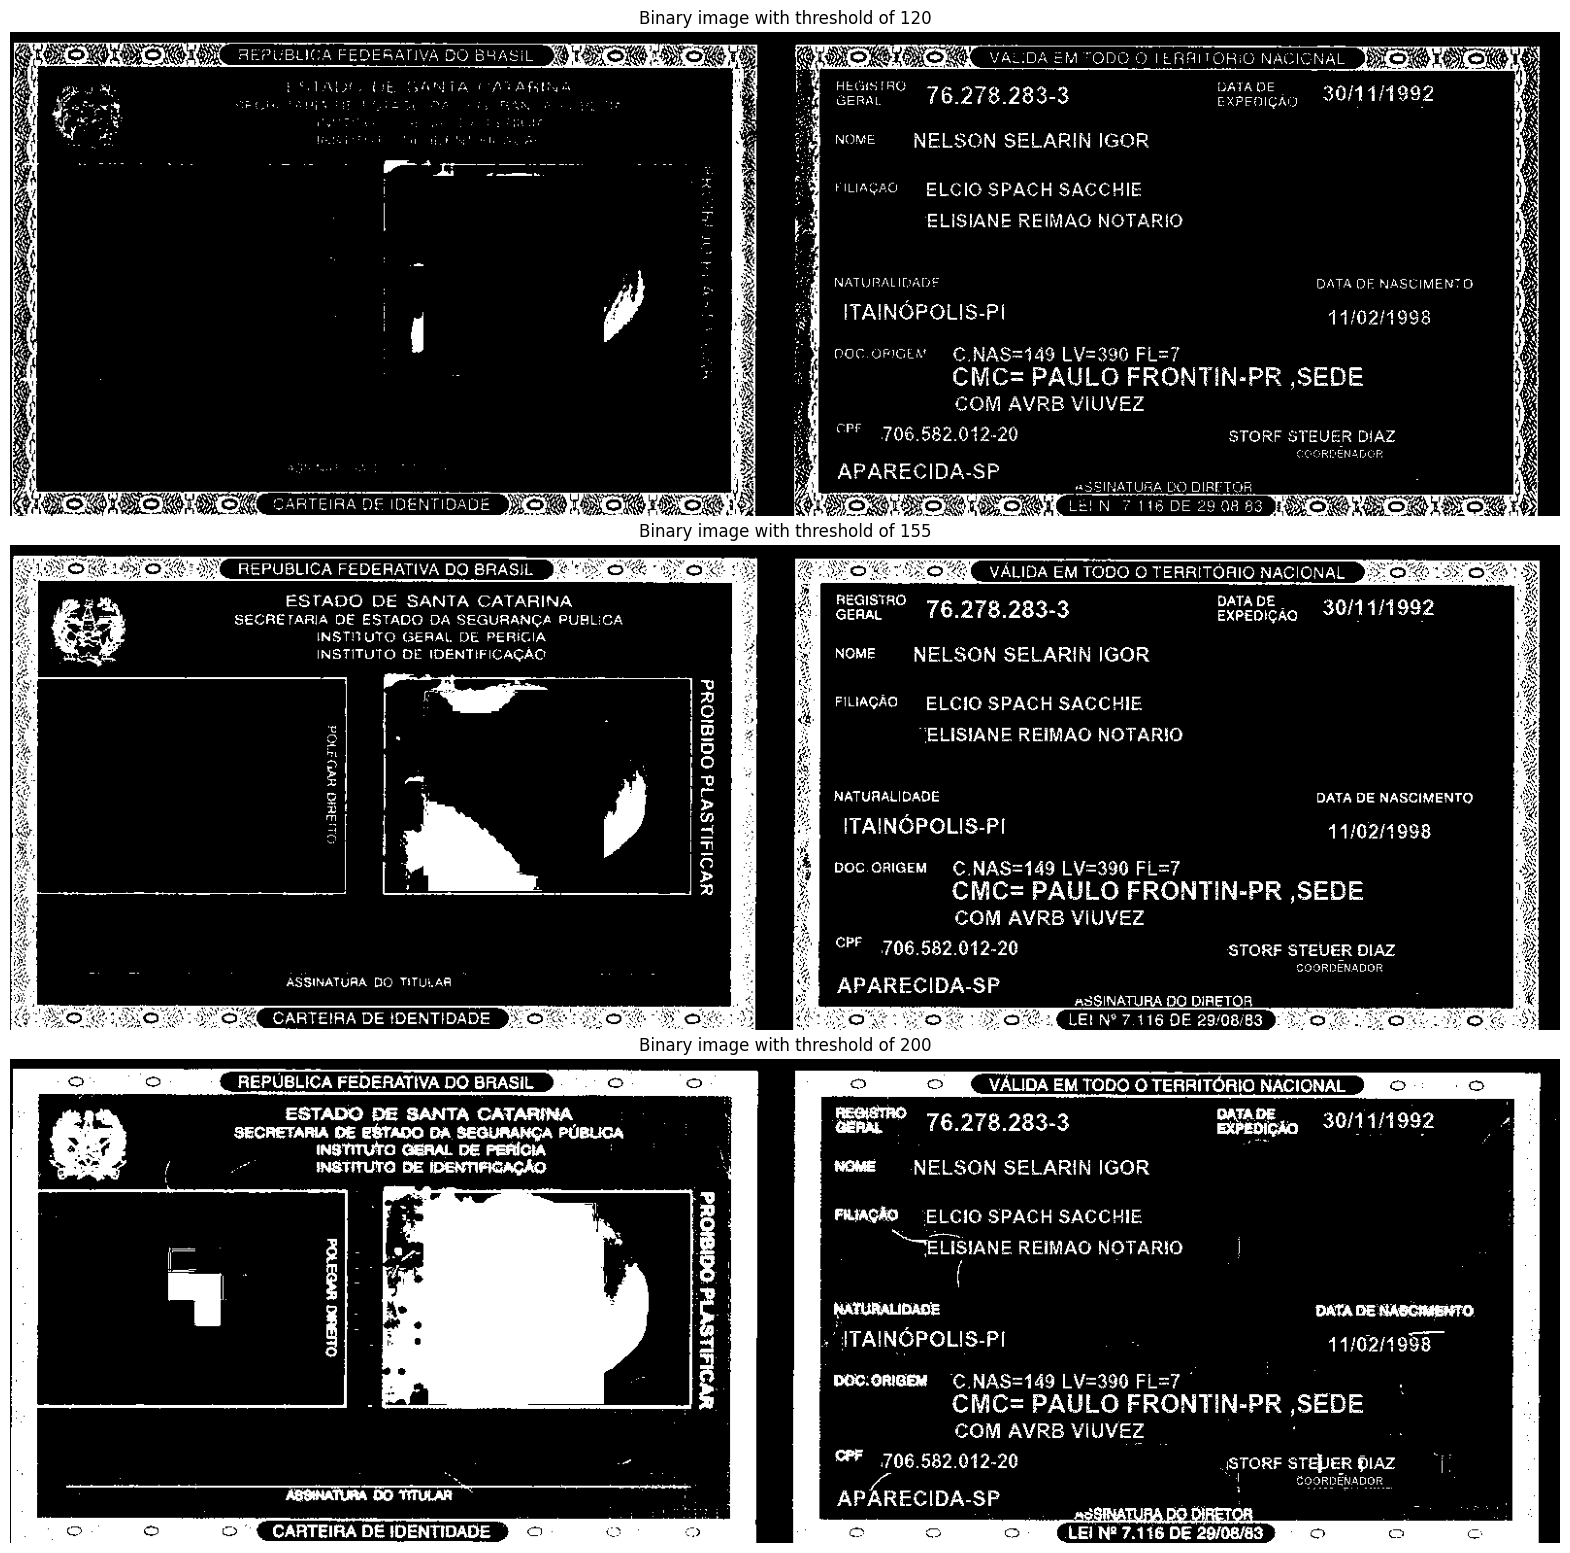

In [93]:
binary_image1 = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)[1]
binary_image2 = cv2.threshold(gray, 155, 255, cv2.THRESH_BINARY_INV)[1]
binary_image3 = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)[1]
#cv2_imshow(binary_image)
plt.subplot(3, 1, 1)
plt.imshow(binary_image1, cmap='gray')
plt.axis('off')
plt.title('Binary image with threshold of 120')
plt.subplot(3, 1, 2)
plt.imshow(binary_image2, cmap='gray')
plt.axis('off')
plt.title('Binary image with threshold of 155')
plt.subplot(3, 1, 3)
plt.imshow(binary_image3, cmap='gray')
plt.axis('off')
plt.title('Binary image with threshold of 200')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

# Segmentação de imagem

Nas imagens foram aplicadas filtros de dilatação afim de aumentar o tamanho e preencher pixels faltando nos objetos



1.   Na primeira temos um dos campos do documento extraído.
2.   Na segunda imagem temos uma aplicação do filtro de dilatação na imagem 1 que aumenta o tamanho do objeto.
3.   Na terceira temos uma segunda aplicação do filtro que aumenta o tamanho do objeto mas ainda não interfere na segmentação das letras



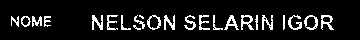

In [94]:
segment = binary_image2[90:130, 840:1200]
cv2_imshow(segment)

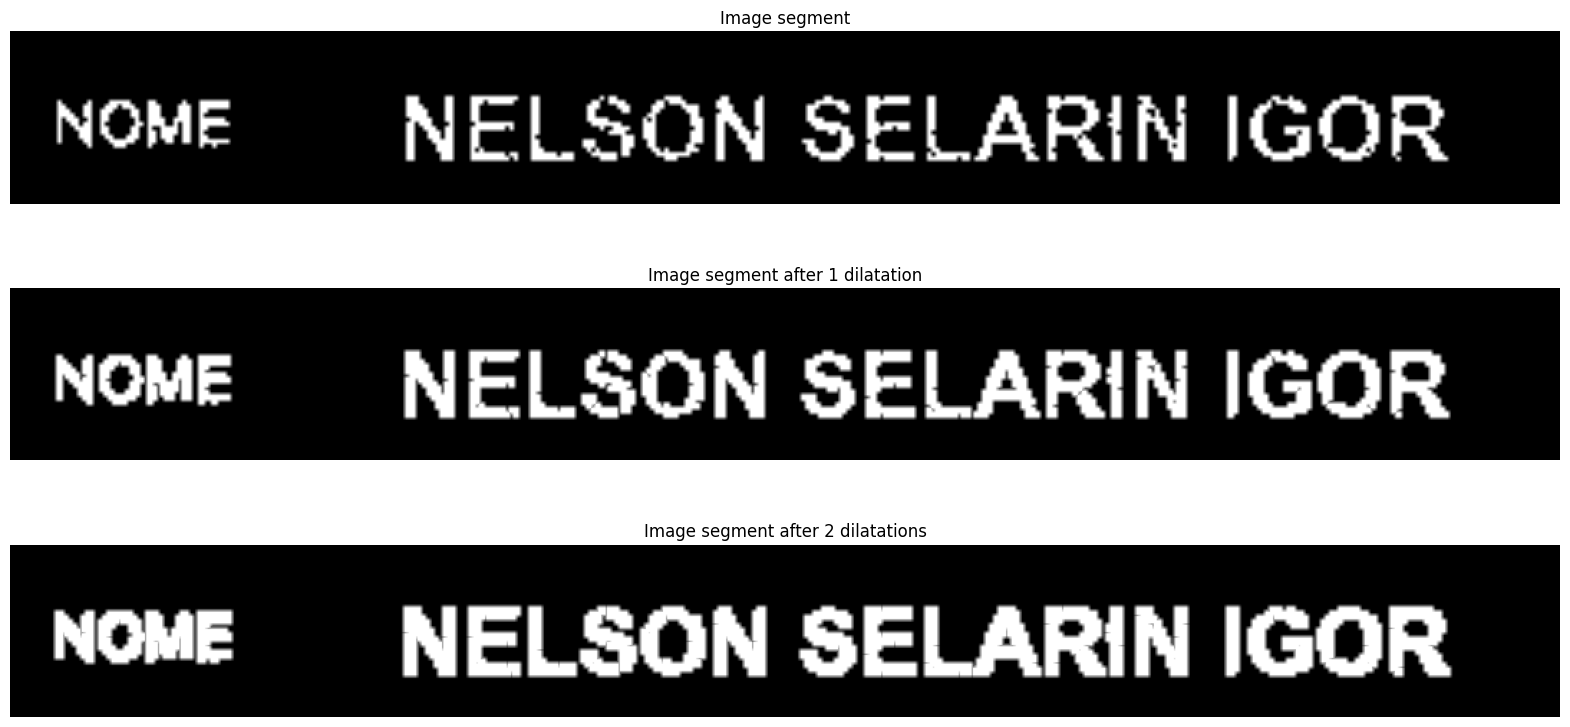

In [95]:
matplotlib.rcParams['figure.figsize'] = (20.0, 10.0)

segment = cv2.resize(segment, (1080, 120))

plt.subplot(3, 1, 1)
plt.imshow(segment, cmap='gray')
plt.axis('off')
plt.title('Image segment')

kernel = np.ones((3,3),np.uint8)
segment = cv2.dilate(segment, kernel, iterations=1)

plt.subplot(3, 1, 2)
plt.imshow(segment, cmap='gray')
plt.axis('off')
plt.title('Image segment after 1 dilatation')

segment = cv2.dilate(segment, kernel, iterations=1)

plt.subplot(3, 1, 3)
plt.imshow(segment, cmap='gray')
plt.axis('off')
plt.title('Image segment after 2 dilatations')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

#Aplicação dos filtros Canny e Roberts nas imagens binarias



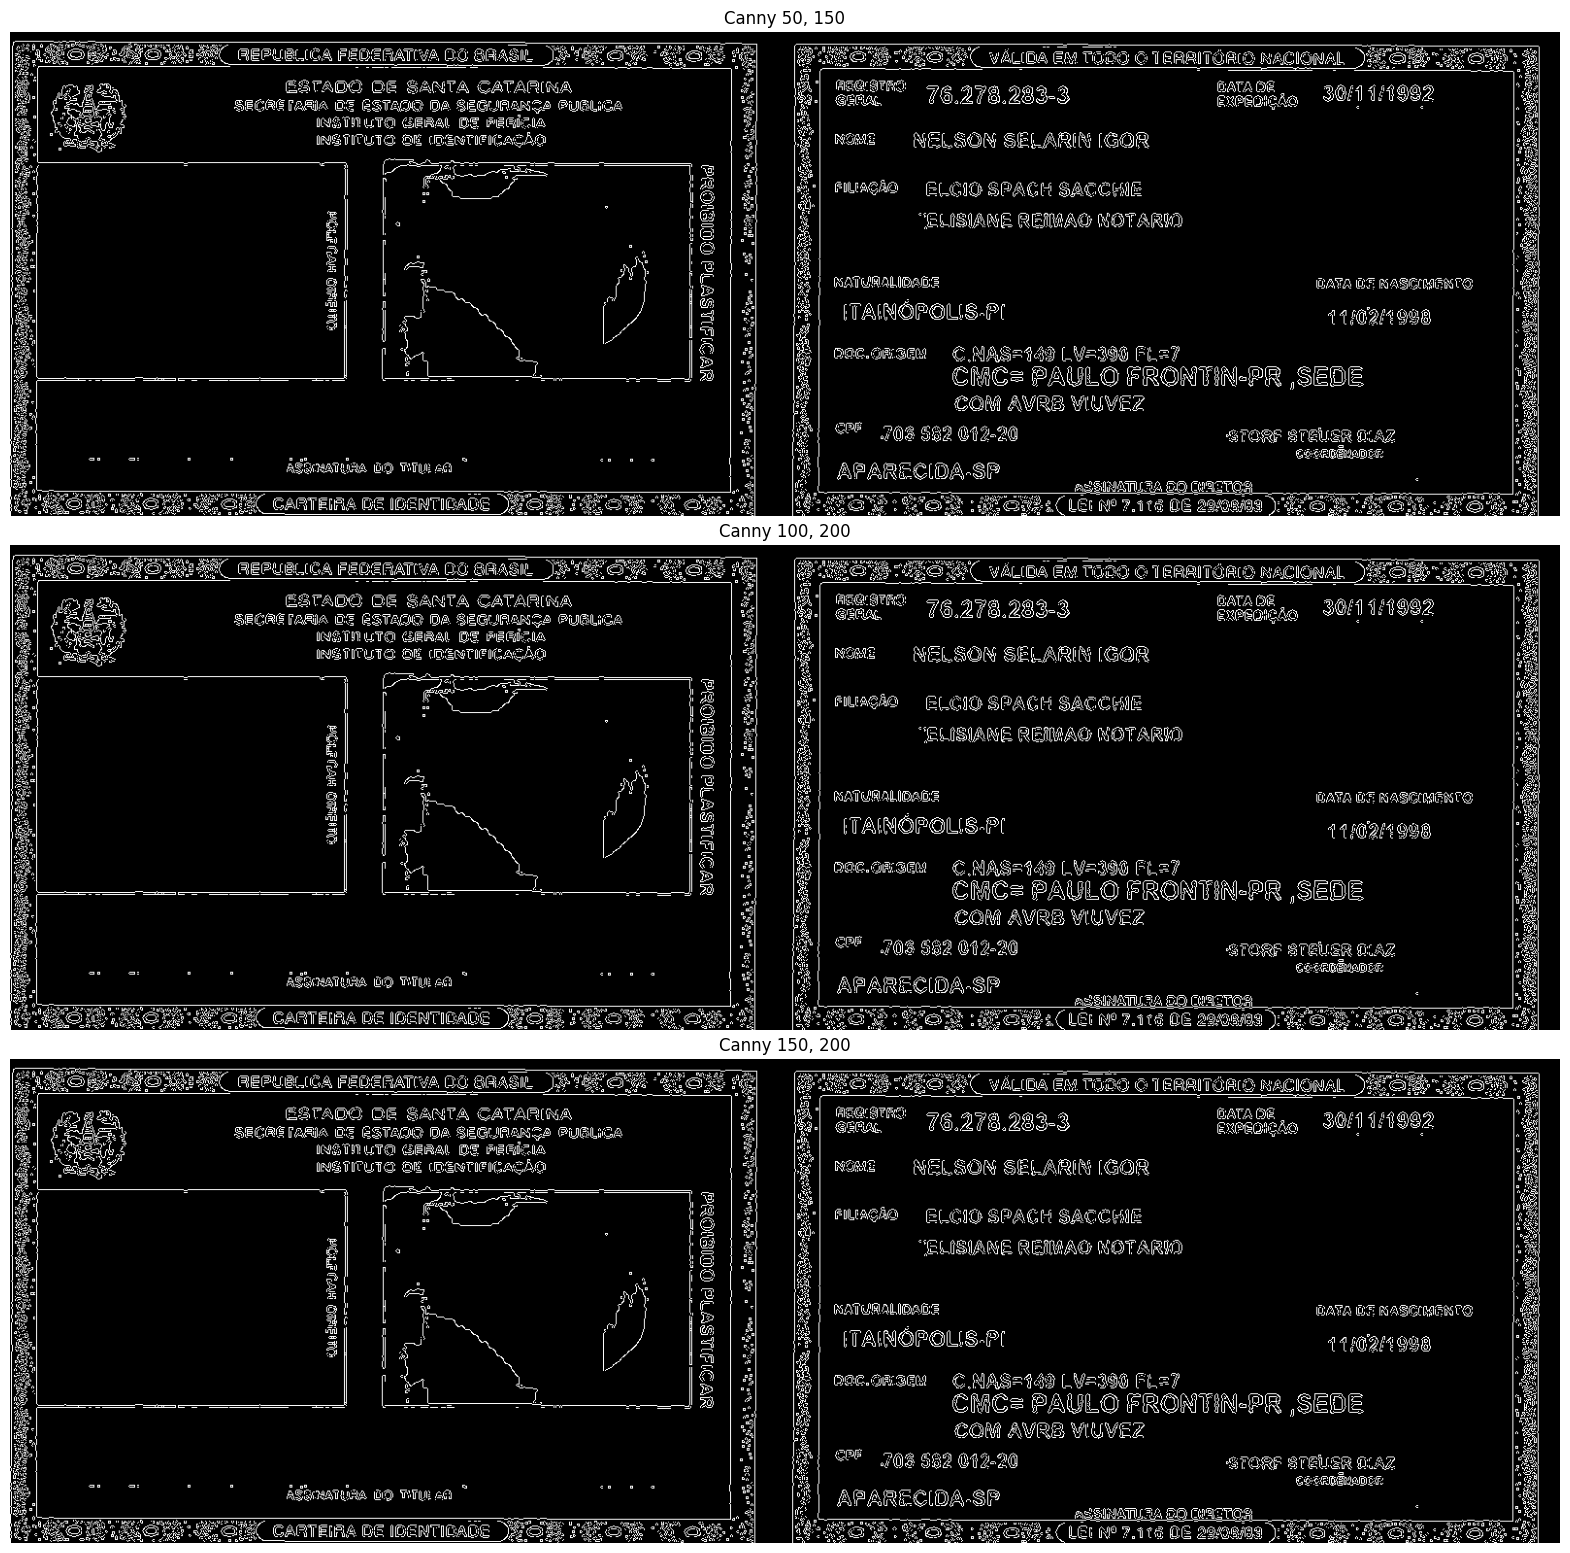

In [96]:
matplotlib.rcParams['figure.figsize'] = (20.0, 20.0)

canny1 = cv2.Canny(binary_image2, 50, 150, L2gradient=True)
canny2 = cv2.Canny(binary_image2, 100, 200, L2gradient=True)
canny3 = cv2.Canny(binary_image2, 150, 200, L2gradient=True)

plt.subplot(3, 1, 1)
plt.imshow(canny1, cmap='gray')
plt.axis('off')
plt.title('Canny 50, 150')
plt.subplot(3, 1, 2)
plt.imshow(canny2, cmap='gray')
plt.axis('off')
plt.title('Canny 100, 200')
plt.subplot(3, 1, 3)
plt.imshow(canny3, cmap='gray')
plt.axis('off')
plt.title('Canny 150, 200')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

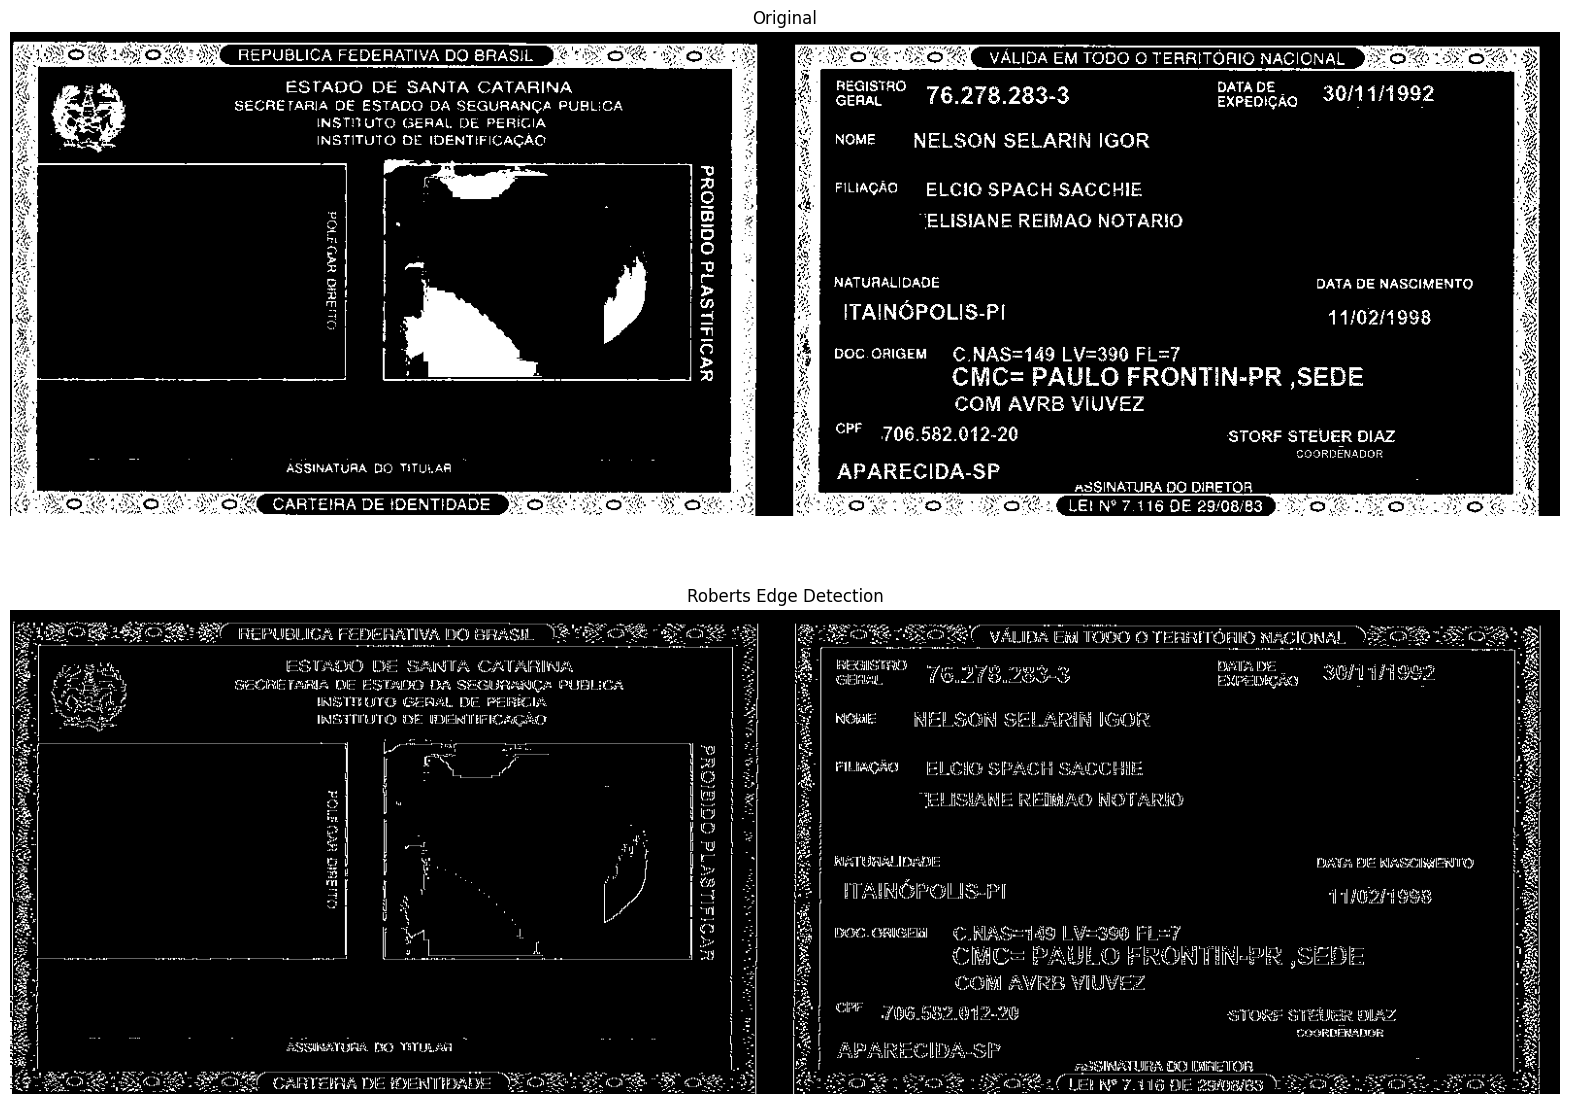

In [97]:
kernel_x = np.array([[1, 0],
                     [0, -1]], dtype=np.float32)

kernel_y = np.array([[0, 1],
                     [-1, 0]], dtype=np.float32)

gx = cv2.filter2D(binary_image2, -1, kernel_x)
gy = cv2.filter2D(binary_image2, -1, kernel_y)

roberts = cv2.sqrt(np.square(gx.astype(np.float32)) + np.square(gy.astype(np.float32)))
roberts = np.uint8(roberts)

plt.figure(figsize=(20, 15))
plt.subplot(2, 1, 1)
plt.imshow(binary_image2, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(roberts, cmap='gray')
plt.title('Roberts Edge Detection')
plt.axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()